如何评估生成的包级时间序列(pkt_len, iat, dir)时序结构保持能力，有没有在真实流量中存在的连续同向段，请求-响应交替，burst 结构和自相关模式，方向切换节律等模式上较好复现了真实流量的时序组织规律，请给出同一领域高水平论文中的最常用的最有价值的指标
给我针对(pkt_len, iat, dir) 的Python代码实现,输入真实/生成的(pkt_len, iat, dir)序列，输出signed size=dir*pkt_len,iat与log1p(iat)的真实/生成ACF曲线对比图、ACF-MAE、ACF-RMSE，加权 ACF 距离DwACF，代码中要方便我设置输出前多少个lag

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def compute_acf(x: np.ndarray, max_lag: int) -> np.ndarray:
    """
    计算一维序列 x 在 1..max_lag 上的 ACF（不含 lag=0）。

    Parameters
    ----------
    x : np.ndarray, shape (T,)
        一维时间序列
    max_lag : int
        最大滞后阶数

    Returns
    -------
    acf_vals : np.ndarray, shape (max_lag,)
        对应 lag=1..max_lag 的 ACF 值
    """
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    T = len(x)

    if T < 2:
        raise ValueError("序列长度至少需要 >= 2")

    if max_lag >= T:
        raise ValueError(f"max_lag={max_lag} 必须小于序列长度 T={T}")

    x_mean = np.mean(x)
    x_centered = x - x_mean

    # 分母：方差项（严格说是样本二阶矩）
    denom = np.sum(x_centered ** 2)
    if np.isclose(denom, 0.0):
        raise ValueError("该序列方差为 0，无法计算 ACF。")

    acf_vals = []
    for lag in range(1, max_lag + 1):
        numerator = np.sum(x_centered[lag:] * x_centered[:-lag])
        acf_k = numerator / denom
        acf_vals.append(acf_k)

    return np.array(acf_vals, dtype=np.float64)


def acf_metrics(real_acf: np.ndarray,
                gen_acf: np.ndarray,
                weight_mode: str = "inverse_lag") -> dict:
    """
    计算 ACF-MAE, ACF-RMSE, DwACF

    Parameters
    ----------
    real_acf : np.ndarray
        真实 ACF, shape (K,)
    gen_acf : np.ndarray
        生成 ACF, shape (K,)
    weight_mode : str
        加权方式，可选:
        - "uniform": 等权
        - "inverse_lag": w_k ∝ 1/k
        - "inverse_sqrt_lag": w_k ∝ 1/sqrt(k)

    Returns
    -------
    metrics : dict
    """
    real_acf = np.asarray(real_acf, dtype=np.float64)
    gen_acf = np.asarray(gen_acf, dtype=np.float64)

    if real_acf.shape != gen_acf.shape:
        raise ValueError("real_acf 和 gen_acf 形状必须一致")

    diff = np.abs(real_acf - gen_acf)
    K = len(diff)

    mae = np.mean(diff)
    rmse = np.sqrt(np.mean((real_acf - gen_acf) ** 2))

    lags = np.arange(1, K + 1, dtype=np.float64)

    if weight_mode == "uniform":
        weights = np.ones(K, dtype=np.float64)
    elif weight_mode == "inverse_lag":
        weights = 1.0 / lags
    elif weight_mode == "inverse_sqrt_lag":
        weights = 1.0 / np.sqrt(lags)
    else:
        raise ValueError(
            "weight_mode 必须是 {'uniform', 'inverse_lag', 'inverse_sqrt_lag'} 之一"
        )

    weights = weights / np.sum(weights)
    dwacf = np.sum(weights * diff)

    return {
        "ACF_MAE": float(mae),
        "ACF_RMSE": float(rmse),
        "DwACF": float(dwacf),
        "weights": weights
    }


def extract_features(seq: np.ndarray,
                     iat_clip_min: float = 0.0) -> dict:
    """
    从 (pkt_len, iat, dir) 提取:
    - signed_size = dir * pkt_len
    - iat
    - log1p(iat)

    Parameters
    ----------
    seq : np.ndarray, shape (T, 3)
        三列依次为 (pkt_len, iat, dir)
    iat_clip_min : float
        为避免 log1p 输入异常，可先对 iat 做下界裁剪:
        iat = max(iat, iat_clip_min)

    Returns
    -------
    features : dict
    """
    seq = np.asarray(seq, dtype=np.float64)

    if seq.ndim != 2 or seq.shape[1] != 3:
        raise ValueError("输入 seq 必须是形状 (T, 3) 的数组，列为 (pkt_len, iat, dir)")

    pkt_len = seq[:, 0]
    iat = seq[:, 1]
    dir_ = seq[:, 2]

    # 防止异常值导致 log1p 出错，至少要保证 iat > -1
    iat_safe = np.maximum(iat, iat_clip_min)

    signed_size = dir_ * pkt_len
    log_iat = np.log1p(iat_safe)

    return {
        "signed_size": signed_size,
        "iat": iat_safe,
        "log1p_iat": log_iat
    }


def plot_acf_comparison(real_acf: np.ndarray,
                        gen_acf: np.ndarray,
                        title: str,
                        save_path: str = None,
                        show: bool = True):
    """
    画真实/生成 ACF 对比图
    """
    K = len(real_acf)
    lags = np.arange(1, K + 1)

    plt.figure(figsize=(8, 4.8))
    plt.plot(lags, real_acf, marker='o', linewidth=1.8, markersize=4, label='Real ACF')
    plt.plot(lags, gen_acf, marker='s', linewidth=1.8, markersize=4, label='Generated ACF')
    plt.axhline(0.0, linestyle='--', linewidth=1.0)
    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')

    if show:
        plt.show()
    else:
        plt.close()


def evaluate_acf_for_traffic(real_seq: np.ndarray,
                             gen_seq: np.ndarray,
                             max_lag: int = 30,
                             weight_mode: str = "inverse_lag",
                             iat_clip_min: float = 0.0,
                             plot: bool = True,
                             save_dir: str = None) -> dict:
    """
    对网络流量 (pkt_len, iat, dir) 做 ACF 评估

    输出三个变量的 ACF 对比与指标:
    - signed_size = dir * pkt_len
    - iat
    - log1p(iat)

    Parameters
    ----------
    real_seq : np.ndarray, shape (T_r, 3)
    gen_seq : np.ndarray, shape (T_g, 3)
    max_lag : int
        输出前多少个 lag
    weight_mode : str
        DwACF 的权重模式
    iat_clip_min : float
        对 iat 下界裁剪
    plot : bool
        是否画图
    save_dir : str or None
        若不为 None，则保存图片到该目录

    Returns
    -------
    results : dict
    """
    real_feat = extract_features(real_seq, iat_clip_min=iat_clip_min)
    gen_feat = extract_features(gen_seq, iat_clip_min=iat_clip_min)

    results = {}

    feature_names = ["signed_size", "iat", "log1p_iat"]

    for feat_name in feature_names:
        real_x = real_feat[feat_name]
        gen_x = gen_feat[feat_name]

        usable_lag = min(max_lag, len(real_x) - 1, len(gen_x) - 1)
        if usable_lag < 1:
            raise ValueError(
                f"{feat_name} 可用 lag 不足。"
                f" len(real)={len(real_x)}, len(gen)={len(gen_x)}, max_lag={max_lag}"
            )

        real_acf = compute_acf(real_x, usable_lag)
        gen_acf = compute_acf(gen_x, usable_lag)
        metrics = acf_metrics(real_acf, gen_acf, weight_mode=weight_mode)

        results[feat_name] = {
            "real_acf": real_acf,
            "gen_acf": gen_acf,
            "metrics": {
                "ACF_MAE": metrics["ACF_MAE"],
                "ACF_RMSE": metrics["ACF_RMSE"],
                "DwACF": metrics["DwACF"]
            }
        }

        if plot:
            title_map = {
                "signed_size": "ACF Comparison: signed_size = dir * pkt_len",
                "iat": "ACF Comparison: iat",
                "log1p_iat": "ACF Comparison: log1p(iat)"
            }

            save_path = None
            if save_dir is not None:
                import os
                os.makedirs(save_dir, exist_ok=True)
                save_path = os.path.join(save_dir, f"acf_{feat_name}.png")

            plot_acf_comparison(
                real_acf=real_acf,
                gen_acf=gen_acf,
                title=title_map[feat_name],
                save_path=save_path,
                show=True
            )

    return results


def print_results(results: dict):
    """
    美观打印结果
    """
    print("=" * 60)
    print("ACF Evaluation Results")
    print("=" * 60)

    for feat_name, item in results.items():
        m = item["metrics"]
        print(f"\n[{feat_name}]")
        print(f"  ACF-MAE  : {m['ACF_MAE']:.6f}")
        print(f"  ACF-RMSE : {m['ACF_RMSE']:.6f}")
        print(f"  DwACF    : {m['DwACF']:.6f}")
    print("=" * 60)


In [3]:
import pandas as pd
from pathlib import Path

#D:\PycharmProjects\My_Paper_exe\Diffusion-Transformer
seq_len = 10000
base_dir = Path.cwd().parent
real_data_path = base_dir / "Data" / "datasets" / "traffic_data" / "data1" / "data.csv"
gen_data_path = base_dir / "Data" / "datasets" / "traffic_data" / "data2" / "data.csv"
#gen_data_path = base_dir / "OUTPUT" / "traffic_1" / "features" / "data_2.csv"
real_df = pd.read_csv(real_data_path, header=0)
real_df.drop(real_df.columns[0], axis=1, inplace=True)
#(117517, 3) int64
real_data = real_df.values
real_pkt_len = real_data[0:seq_len, 0]
real_iat = real_data[0:seq_len, 1]
real_dir = real_data[0:seq_len, 2]

gen_df = pd.read_csv(gen_data_path, header=0)
gen_df.drop(gen_df.columns[0], axis=1, inplace=True)
#(117517, 3) int64
gen_data = gen_df.values
gen_pkt_len = gen_data[0:seq_len, 0]
gen_iat = gen_data[0:seq_len, 1]
gen_dir = gen_data[0:seq_len, 2]

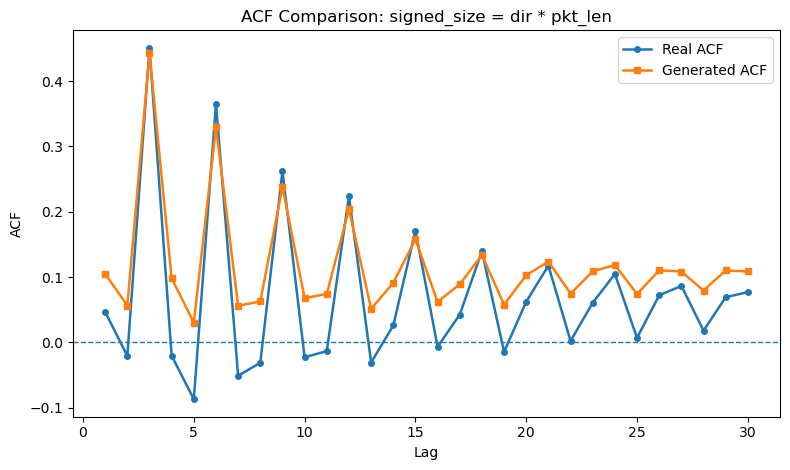

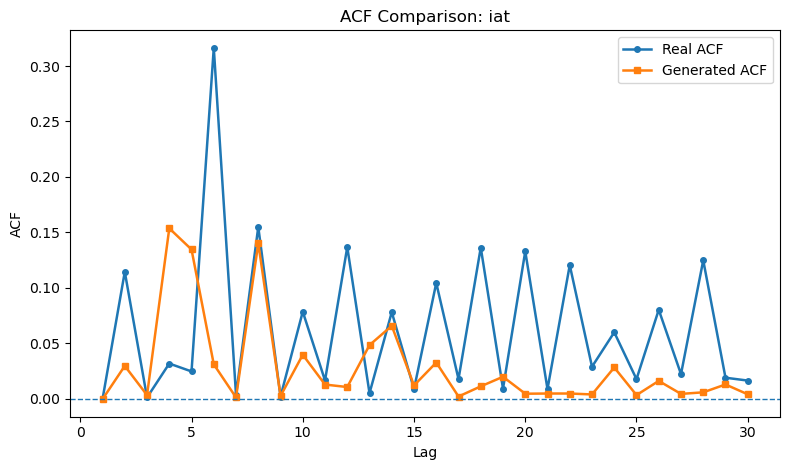

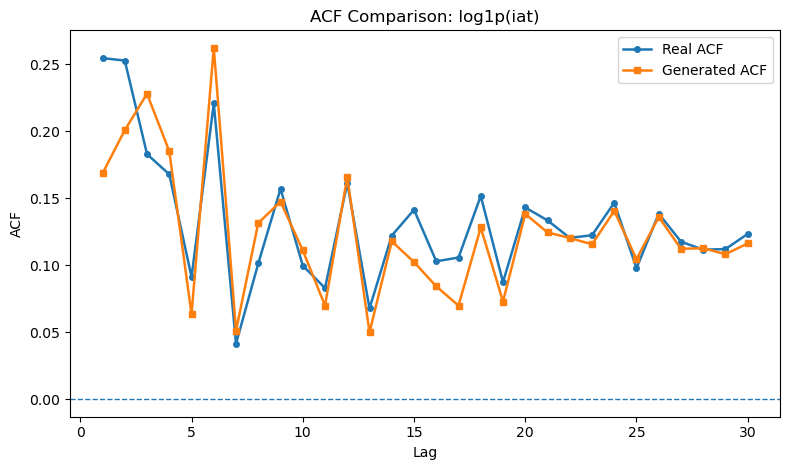

ACF Evaluation Results

[signed_size]
  ACF-MAE  : 0.054578
  ACF-RMSE : 0.063667
  DwACF    : 0.062130

[iat]
  ACF-MAE  : 0.053743
  ACF-RMSE : 0.083112
  DwACF    : 0.050176

[log1p_iat]
  ACF-MAE  : 0.018510
  ACF-RMSE : 0.026420
  DwACF    : 0.041199


In [4]:
# np.random.seed(42)
#
#     # 构造一个示例真实序列 (T, 3)
#     T_real = 300
#     real_pkt_len = np.random.choice([60, 200, 512, 1200, 1500], size=T_real)
#     real_iat = np.random.exponential(scale=100.0, size=T_real)  # 例如微秒级或任意单位
#     real_dir = np.random.choice([-1, 1], size=T_real, p=[0.45, 0.55])
#
#     real_seq = np.stack([real_pkt_len, real_iat, real_dir], axis=1)
#
#     # 构造一个示例生成序列
#     T_gen = 280
#     gen_pkt_len = np.random.choice([60, 180, 500, 1100, 1500], size=T_gen)
#     gen_iat = np.random.exponential(scale=120.0, size=T_gen)
#     gen_dir = np.random.choice([-1, 1], size=T_gen, p=[0.5, 0.5])
#
#     gen_seq = np.stack([gen_pkt_len, gen_iat, gen_dir], axis=1)

    # 评估
results = evaluate_acf_for_traffic(
    real_seq=real_data,
    gen_seq=gen_data,
    max_lag=30,                 # 这里改你想输出前多少个 lag
    weight_mode="inverse_lag",  # 可改为 "uniform" 或"inverse_lag"或 "inverse_sqrt_lag"
    iat_clip_min=0.0,
    plot=True,
    save_dir=None               # 例如 "./acf_outputs"
)

print_results(results)